# 06: Frontdoor, IV, and Natural Experiments

The earlier lessons focused on the most common observational workflow: draw a graph, identify a backdoor adjustment set, estimate an average effect, and then stress-test the result. That is the right starting point, but many real causal questions have a harder problem: some important confounder is not measured well enough to adjust for directly.

We introduce three families of designs that can still identify causal effects under stronger structural assumptions:

- **Frontdoor identification:** use a measured mediator when treatment and outcome share an unobserved cause.
- **Instrumental variables:** use an external source of treatment variation that affects the outcome only through the treatment.
- **Natural-experiment designs:** use discontinuities, rollouts, timing, or assignment rules that create quasi-random variation.

The goal is to learn what each design buys, what it assumes, how to implement a transparent worked example, and how DoWhy fits into the workflow.


## Learning Goals

By the end, you should be able to:

- Explain why ordinary backdoor adjustment fails when an important common cause is unobserved.
- Recognize the three frontdoor conditions and estimate a frontdoor effect with DoWhy.
- Recognize the relevance, exclusion, and independence assumptions behind instrumental variables.
- Estimate an IV effect with a manual Wald estimator, a simple two-stage regression, and DoWhy.
- Build transparent regression-discontinuity and difference-in-differences examples as natural-experiment designs.
- Compare identification strategies by asking: where did the causal variation come from, and what assumption would break the estimate?


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use mostly simulated or semi-synthetic observational datasets to study **Frontdoor, IV, And Natural Experiments**. DoWhy is mainly about causal modeling discipline: graph, estimand, estimator, and refuter. A controlled dataset lets us show how a change in assumptions changes the estimand and the credibility of the estimate.

Read each row as an observed unit in a business or policy system. The treatment, outcome, common causes, instruments, mediators, and anomaly indicators are named to mirror applied causal workflows and keep the examples close to realistic analysis language. The experiment shows a setting where ordinary backdoor adjustment is unavailable and identification must come from mediator or instrument structure. The experiment shows a setting where treatment choice is endogenous and identification must come from a source of quasi-random variation.

The simulation is designed to make the identifying assumptions and diagnostic checks visible. It is meant to expose the assumptions that would be hidden in real data, where the true counterfactual outcome is unavailable.


## Mathematical Foundation

<!-- math-foundation-note -->

Frontdoor and IV designs identify effects when ordinary backdoor adjustment is not enough. The frontdoor estimand is

$$
\Pr(Y\mid do(D=d))=\sum_m \Pr(M=m\mid D=d)\sum_{d'}\Pr(Y\mid M=m,D=d')\Pr(D=d').
$$

For an instrument $Z$, a simple Wald estimand is

$$
\tau_{IV}=\frac{\mathbb{E}(Y\mid Z=1)-\mathbb{E}(Y\mid Z=0)}{\mathbb{E}(D\mid Z=1)-\mathbb{E}(D\mid Z=0)}.
$$


## When Backdoor Adjustment Needs More Structure

Backdoor adjustment is powerful when the important confounders are measured. If a variable affects both treatment and outcome, and we observe it, we can often block the non-causal path by conditioning on it.

The problem is that many important causes are not directly observed. In product, policy, education, marketplace, and health settings, latent motivation, latent need, hidden quality, exposure opportunity, or local assignment rules may shape both who gets treated and what outcome they would have had anyway.

We start by creating a controlled failure case. We will know the true effect because the data are simulated. Then we will hide the confounder and watch ordinary adjustment drift away from the truth. That gives the later designs a clear purpose: they are alternative ways to get credible causal variation when the usual adjustment path is blocked.





## Tutorial Workflow

#### Setup

This setup block imports the core packages, applies a small set of warning filters, creates output folders, and fixes the plotting style. The warning filters keep the lesson readable while preserving normal errors. The generated tables and figures use a `06_` prefix so outputs from different tutorial lessons do not overwrite each other.


In [ ]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import warnings
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*disp.*iprint.*L-BFGS-B.*")
warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", module="seaborn.categorical")
warnings.filterwarnings("ignore", module="pydot.dot_parser")
import dowhy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
# Compatibility shim for DoWhy versions that expect the older NetworkX d_separated API.
if not hasattr(nx.algorithms, "d_separated"):
    from networkx.algorithms.d_separation import is_d_separator
    nx.algorithms.d_separated = is_d_separator
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
# Compatibility shim for DoWhy estimators written against older pandas Series integer indexing.
if not getattr(pd.Series, "_dowhy_integer_position_patch", False):
    _original_series_getitem = pd.Series.__getitem__
    def _dowhy_series_getitem_compat(self, key):
        try:
            return _original_series_getitem(self, key)
        except KeyError:
            if isinstance(key, int) and key not in self.index:
                return self.iloc[key]
            raise
    pd.Series.__getitem__ = _dowhy_series_getitem_compat
    pd.Series._dowhy_integer_position_patch = True
import seaborn as sns
import statsmodels.formula.api as smf
from dowhy import CausalModel
from IPython.display import display
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", context="notebook")
# Resolve paths so the notebook works both from the repository root and from inside JupyterLab.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "notebooks" / "tutorials" / "dowhy").exists():
        PROJECT_ROOT = candidate
        break
else:
    PROJECT_ROOT = Path.cwd()
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "dowhy"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(606)
print(f"DoWhy version: {dowhy.__version__}")
print(f"Notebook directory: {NOTEBOOK_DIR}")


The environment is ready once the DoWhy version and output folders print successfully. From this point on, every saved output lands under `lessons/tutorials/dowhy/outputs`, with figures and tables separated for easier browsing.


### Strategy Map

Before writing estimators, it helps to name the designs side by side. The table below is a compact map of the identification strategies in this lesson. Read it as a checklist: each method needs a particular source of causal variation, and each method has a characteristic failure mode.


| strategy | main source of identification | works best when | main risk |
| --- | --- | --- | --- |
| Backdoor adjustment | Condition on measured common causes of treatment and outcome | The important confounders are observed and measured well | Hidden confounding remains after adjustment |
| Frontdoor | A measured mediator carries the treatment effect | Treatment affects outcome only through the mediator, and mediator-outcome confounding is controlled | Direct effects or mediator-outcome confounding violate the design |
| Instrumental variables | An external variable shifts treatment but has no direct path to outcome | The instrument is relevant, independent, and satisfies exclusion | The instrument affects the outcome through another path |
| Regression discontinuity | Treatment probability jumps at a cutoff in a running variable | Units cannot precisely manipulate the cutoff and the outcome is smooth around it | Sorting around the cutoff or unrelated discontinuities |
| Difference-in-differences | A treated group changes after treatment relative to a comparison group | The groups would have followed parallel trends without treatment | The comparison group is not a credible counterfactual trend |


The common theme is that none of these designs is just a modeling trick. Each one is a story about where the identifying variation comes from. A good analysis explains that story before presenting the estimate.


#### A Small Graph Helper

DoWhy accepts graph descriptions in formats such as DOT. To keep the lesson readable, this helper turns a list of directed edges into a simple DOT graph string. We will use it for frontdoor and IV examples where DoWhy can identify the estimand directly.


In [2]:
def edges_to_dot(edges, graph_name="causal_graph"):
    """
    Create a compact DOT graph string from a list of directed edges.
    
    Parameters
    ----------
    edges : object
        Collection of directed edges used to build a graph string or diagram.
    graph_name : str
        Readable label for `graph`.
    
    Returns
    -------
    str
        DOT graph string that can be passed to DoWhy or Graphviz-style renderers.
    """
    edge_lines = [f"    {left} -> {right};" for left, right in edges]
    return "digraph " + graph_name + " {\n" + "\n".join(edge_lines) + "\n}"
example_dot = edges_to_dot(
    [
        ("observed_cause", "treatment"),
        ("observed_cause", "outcome"),
        ("treatment", "outcome"),
    ],
    graph_name="example",
)
print(example_dot)


digraph example {
    observed_cause -> treatment;
    observed_cause -> outcome;
    treatment -> outcome;
}


The helper is minimal. It keeps the causal structure visible in the code block instead of hiding the graph in a separate file.





## Diagnostics and Interpretation

### A Controlled Failure Case: Hidden Confounding

The next dataset has a true treatment effect of `1.50`. The treatment is `feature_exposure`, the outcome is `weekly_value`, and there is an unobserved variable called `unobserved_motivation` that affects both.

We will keep the hidden variable in the simulated dataframe only so that we can compare what would happen in an impossible oracle analysis. In a real observational dataset, this variable would be missing, and that is exactly the challenge.


In [3]:
# Define reusable helpers for the A Controlled Failure Case: Hidden Confounding section.
def make_hidden_confounding_data(n=6_000, seed=606):
    """
    Idea: Construct the hidden confounding data used in the A Controlled Failure Case: Hidden Confounding section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n : int
        Number of observations or repetitions to generate.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple
        Tuple containing df, true_effect.
    """
    local_rng = np.random.default_rng(seed)
    pre_activity = local_rng.normal(loc=0.0, scale=1.0, size=n)
    account_age_weeks = local_rng.gamma(shape=5.0, scale=8.0, size=n)
    unobserved_motivation = local_rng.normal(loc=0.0, scale=1.0, size=n)
    # A noisy observed proxy is helpful, but it is not the same as the hidden cause itself.
    proxy_engagement = (
        0.70 * unobserved_motivation
        + 0.45 * pre_activity
        + local_rng.normal(loc=0.0, scale=0.90, size=n)
    )
    true_effect = 1.50
    feature_exposure = (
        0.95 * unobserved_motivation
        + 0.45 * pre_activity
        + 0.015 * account_age_weeks
        + local_rng.normal(loc=0.0, scale=1.00, size=n)
    )
    weekly_value = (
        true_effect * feature_exposure
        + 1.25 * unobserved_motivation
        + 0.35 * pre_activity
        + 0.010 * account_age_weeks
        + local_rng.normal(loc=0.0, scale=1.20, size=n)
    )
    df = pd.DataFrame(
        {
            "pre_activity": pre_activity,
            "account_age_weeks": account_age_weeks,
            "proxy_engagement": proxy_engagement,
            "unobserved_motivation": unobserved_motivation,
            "feature_exposure": feature_exposure,
            "weekly_value": weekly_value,
        }
    )
    return df, true_effect
hidden_df, hidden_true_effect = make_hidden_confounding_data()
print(f"Rows: {len(hidden_df):,}")
print(f"True treatment effect used in the simulation: {hidden_true_effect:.2f}")
display(hidden_df.head())


Rows: 6,000
True treatment effect used in the simulation: 1.50


,pre_activity,account_age_weeks,proxy_engagement,unobserved_motivation,feature_exposure,weekly_value
0,0.2597,46.9620,0.6869,1.0567,2.0448,6.5141
1,1.6213,28.4868,-0.0787,-0.0828,1.4323,1.7884
2,0.3564,17.6493,-0.9203,-0.8517,-1.6836,-3.4640
3,0.9715,21.7265,-0.5835,0.1214,0.0407,-0.7740
4,0.7361,49.0277,0.1901,-0.1348,0.2330,3.6733


The data look ordinary: observed pre-treatment variables, a treatment-like exposure, and an outcome. The danger is not visible in the first rows. The danger is structural: the treatment and outcome share a cause that we pretend not to observe.


### Compare Naive, Proxy, and Oracle Adjustment

The code below fits four simple linear regressions. The first is naive. The second adjusts for ordinary observed controls. The third also adjusts for a noisy proxy of the hidden cause. The fourth includes the hidden cause itself, which is unavailable in practice and helps us see the benchmark.

The important number is the coefficient on `feature_exposure`. Since the true effect is `1.50`, estimates far above that value are picking up non-causal association from hidden motivation.


In [4]:
# Define reusable helpers for the Compare Naive, Proxy, And Oracle Adjustment section.
def coefficient_table(formula, data, label, coefficient="feature_exposure"):
    """
    Idea: Assemble a DataFrame for the coefficient table so the result can be displayed and saved consistently.
    
    Parameters
    ----------
    formula : object
        Context-specific input used for formula in this helper.
    data : array-like or pd.DataFrame
        Data passed into the demonstrated method.
    label : str
        Short label attached to a scenario, method, or plotted result.
    coefficient : object
        Inference quantity used to construct intervals or tests.
    
    Returns
    -------
    dict[str, float]
        Coefficient summary row for the requested model term.
    """
    model = smf.ols(formula, data=data).fit(cov_type="HC1")
    return {
        "model": label,
        "estimate": model.params[coefficient],
        "std_error": model.bse[coefficient],
        "ci_95_lower": model.conf_int().loc[coefficient, 0],
        "ci_95_upper": model.conf_int().loc[coefficient, 1],
    }
hidden_estimates = pd.DataFrame(
    [
        coefficient_table("weekly_value ~ feature_exposure", hidden_df, "naive association"),
        coefficient_table(
            "weekly_value ~ feature_exposure + pre_activity + account_age_weeks",
            hidden_df,
            "observed controls only",
        ),
        coefficient_table(
            "weekly_value ~ feature_exposure + pre_activity + account_age_weeks + proxy_engagement",
            hidden_df,
            "observed controls plus proxy",
        ),
        coefficient_table(
            "weekly_value ~ feature_exposure + pre_activity + account_age_weeks + unobserved_motivation",
            hidden_df,
            "oracle hidden confounder",
        ),
    ]
)
hidden_estimates["true_effect"] = hidden_true_effect
hidden_estimates["bias"] = hidden_estimates["estimate"] - hidden_estimates["true_effect"]
hidden_estimates.to_csv(TABLE_DIR / "06_hidden_confounding_estimates.csv", index=False)
display(hidden_estimates)


,model,estimate,std_error,ci_95_lower,ci_95_upper,true_effect,bias
0,naive association,2.1598,0.0129,2.1346,2.1851,1.5000,0.6598
1,observed controls only,2.1532,0.0139,2.1259,2.1805,1.5000,0.6532
2,observed controls plus proxy,1.9990,0.0150,1.9696,2.0284,1.5000,0.4990
3,oracle hidden confounder,1.5203,0.0154,1.4901,1.5506,1.5000,0.0203


The oracle model is close to the true effect because it includes the real common cause. The other models are too high because exposure is partly a signal of latent motivation. A proxy helps somewhat, and a noisy proxy still leaves residual confounding risk along the backdoor path.


#### Plot the Hidden-Confounding Bias

A plot makes the lesson more immediate. The dashed line is the true effect. Each point is the treatment coefficient from a different adjustment strategy.


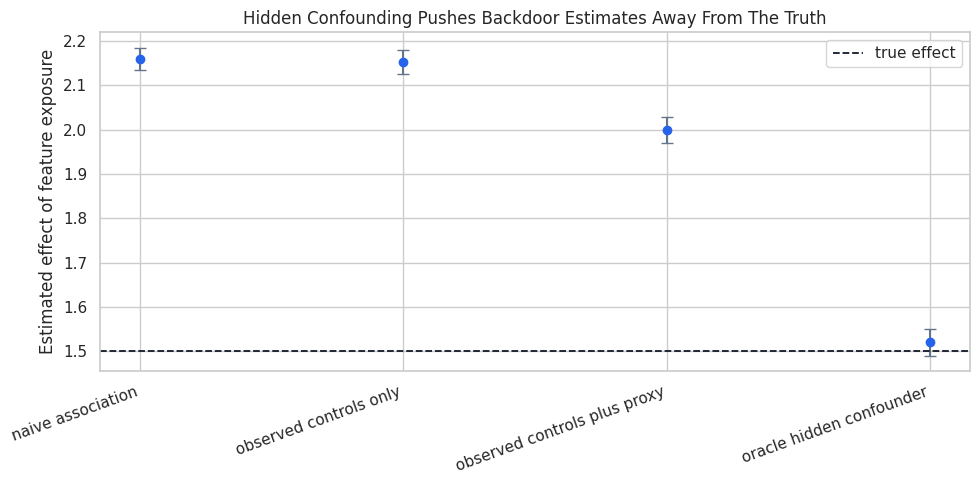

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = hidden_estimates.copy()
plot_df["lower_error"] = plot_df["estimate"] - plot_df["ci_95_lower"]
plot_df["upper_error"] = plot_df["ci_95_upper"] - plot_df["estimate"]
ax.errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df["estimate"],
    yerr=[plot_df["lower_error"], plot_df["upper_error"]],
    fmt="o",
    color="#2563eb",
    ecolor="#64748b",
    capsize=4,
)
ax.axhline(hidden_true_effect, color="#111827", linestyle="--", linewidth=1.3, label="true effect")
ax.set_xticks(np.arange(len(plot_df)))
ax.set_xticklabels(plot_df["model"], rotation=20, ha="right")
ax.set_ylabel("Estimated effect of feature exposure")
ax.set_title("Hidden Confounding Pushes Backdoor Estimates Away From The Truth")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_hidden_confounding_bias.png", dpi=160, bbox_inches="tight")
plt.show()


This is why alternative identification strategies matter. If hidden confounding is plausible, adding more flexible models to the same observed covariates may make predictions better without making the causal effect credible.




### Frontdoor Identification: The Idea

Frontdoor identification can work when the treatment-outcome relationship is confounded, but the treatment effect flows through a measured mediator.

For a treatment `A`, mediator `M`, outcome `Y`, and hidden confounder `U`, the core story is:

- `U` affects `A` and `Y`, so the direct treatment-outcome association is confounded.
- `A` affects `M`.
- `M` affects `Y`.
- All of the causal effect of `A` on `Y` flows through `M`.
- There is no unblocked confounding between `A` and `M`.
- After conditioning on `A`, there is no unblocked confounding between `M` and `Y`.

This is a strong design. It is useful to learn because it shows how a mediator can sometimes rescue identification when treatment assignment itself is confounded.





## Reporting and Takeaways

### Frontdoor Assumption Checklist

This table translates the frontdoor design into practical questions. If these assumptions are implausible, the estimate should be described as a sensitivity or teaching exercise rather than a credible causal conclusion.


| condition | question to ask |
| --- | --- |
| Treatment affects the mediator | Does feature exposure clearly move engagement depth? |
| Mediator carries the treatment effect | Is there a direct path from exposure to future value that bypasses engagement depth? |
| No unblocked treatment-mediator confounding | Could a hidden variable affect both exposure and the mediator? |
| Mediator-outcome confounding is blocked after treatment | Once exposure is held fixed, are mediator and outcome still confounded by hidden causes? |


The checklist should be treated as part of the analysis because it records the assumptions behind the estimate. Frontdoor is persuasive only when the mediator has a believable structural role.




### Simulate a Frontdoor Setting

The next data-generating process is constructed to satisfy the frontdoor story. Hidden motivation confounds exposure and future value, but it does not affect the mediator directly. Exposure moves `engagement_depth`, and `engagement_depth` moves `weekly_value`. The true total effect is the product of those two path coefficients.


In [6]:
# Define reusable helpers for the Simulate A Frontdoor Setting section.
def make_frontdoor_data(n=7_000, seed=616):
    """
    Idea: Construct the frontdoor data used in the Simulate A Frontdoor Setting section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n : int
        Number of observations or repetitions to generate.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple
        Tuple containing df, true_total_effect, exposure_to_mediator, mediator_to_outcome.
    """
    local_rng = np.random.default_rng(seed)
    unobserved_motivation = local_rng.normal(size=n)
    feature_exposure = 0.80 * unobserved_motivation + local_rng.normal(scale=1.00, size=n)
    exposure_to_mediator = 1.25
    mediator_to_outcome = 1.80
    engagement_depth = exposure_to_mediator * feature_exposure + local_rng.normal(scale=1.00, size=n)
    weekly_value = mediator_to_outcome * engagement_depth + 1.35 * unobserved_motivation + local_rng.normal(scale=1.20, size=n)
    df = pd.DataFrame(
        {
            "feature_exposure": feature_exposure,
            "engagement_depth": engagement_depth,
            "weekly_value": weekly_value,
        }
    )
    true_total_effect = exposure_to_mediator * mediator_to_outcome
    return df, true_total_effect, exposure_to_mediator, mediator_to_outcome
frontdoor_df, frontdoor_true_effect, true_a_to_m, true_m_to_y = make_frontdoor_data()
print(f"Rows: {len(frontdoor_df):,}")
print(f"True exposure-to-mediator effect: {true_a_to_m:.2f}")
print(f"True mediator-to-outcome effect: {true_m_to_y:.2f}")
print(f"True total frontdoor effect: {frontdoor_true_effect:.2f}")
display(frontdoor_df.head())


Rows: 7,000
True exposure-to-mediator effect: 1.25
True mediator-to-outcome effect: 1.80
True total frontdoor effect: 2.25


,feature_exposure,engagement_depth,weekly_value
0,-0.0294,0.4965,1.3451
1,-2.0382,-2.7053,-8.3668
2,-2.6281,-2.8134,-7.1173
3,0.9666,0.8922,0.9597
4,0.1547,-0.1402,1.2644


Unlike the hidden-confounding example, this dataset includes a mediator that was designed to carry the effect. The next cells estimate the effect through that mediator instead of trusting the raw exposure-outcome association.


### Manual Linear Frontdoor Calculation

In this linear teaching setup, the frontdoor effect can be seen as two pieces:

1. Estimate how much `feature_exposure` changes `engagement_depth`.
2. Estimate how much `engagement_depth` changes `weekly_value` after controlling for `feature_exposure`.
3. Multiply the two pieces.

The multiplication serves a different role than the general frontdoor formula for every setting. It is a clear linear special case that helps build intuition.


In [7]:
# Fit or evaluate the model objects used in the Manual Linear Frontdoor Calculation section.
frontdoor_stage_1 = smf.ols("engagement_depth ~ feature_exposure", data=frontdoor_df).fit(cov_type="HC1")
frontdoor_stage_2 = smf.ols("weekly_value ~ feature_exposure + engagement_depth", data=frontdoor_df).fit(cov_type="HC1")
frontdoor_naive = smf.ols("weekly_value ~ feature_exposure", data=frontdoor_df).fit(cov_type="HC1")
manual_frontdoor_effect = (
    frontdoor_stage_1.params["feature_exposure"]
    * frontdoor_stage_2.params["engagement_depth"]
)
manual_frontdoor_table = pd.DataFrame(
    [
        {
            "quantity": "naive exposure-outcome slope",
            "estimate": frontdoor_naive.params["feature_exposure"],
            "target": frontdoor_true_effect,
        },
        {
            "quantity": "exposure-to-mediator stage",
            "estimate": frontdoor_stage_1.params["feature_exposure"],
            "target": true_a_to_m,
        },
        {
            "quantity": "mediator-to-outcome stage",
            "estimate": frontdoor_stage_2.params["engagement_depth"],
            "target": true_m_to_y,
        },
        {
            "quantity": "manual frontdoor product",
            "estimate": manual_frontdoor_effect,
            "target": frontdoor_true_effect,
        },
    ]
)
manual_frontdoor_table.to_csv(TABLE_DIR / "06_manual_frontdoor_estimate.csv", index=False)
display(manual_frontdoor_table)


,quantity,estimate,target
0,naive exposure-outcome slope,2.8922,2.2500
1,exposure-to-mediator stage,1.2532,1.2500
2,mediator-to-outcome stage,1.8212,1.8000
3,manual frontdoor product,2.2823,2.2500


The naive exposure-outcome slope is biased because exposure carries hidden motivation. The product of the two frontdoor stages lands much closer to the true total effect because it uses the mediator path rather than the confounded direct association.


### Identify the Frontdoor Estimand with DoWhy

Now we encode the same graph in DoWhy. Notice that `unobserved_motivation` appears in the graph but not in the dataframe. That is deliberate: the graph tells DoWhy that a hidden common cause exists, while the mediator supplies a possible frontdoor path.


In [8]:
frontdoor_graph = edges_to_dot(
    [
        ("unobserved_motivation", "feature_exposure"),
        ("unobserved_motivation", "weekly_value"),
        ("feature_exposure", "engagement_depth"),
        ("engagement_depth", "weekly_value"),
    ],
    graph_name="frontdoor_graph",
)
frontdoor_model = CausalModel(
    data=frontdoor_df,
    treatment="feature_exposure",
    outcome="weekly_value",
    graph=frontdoor_graph,
)
frontdoor_estimand = frontdoor_model.identify_effect(proceed_when_unidentifiable=True)
print(frontdoor_estimand)


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
No such variable(s) found!

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
Estimand expression:
 ⎡         d                               d                             ⎤
E⎢───────────────────(weeklyᵥₐₗᵤₑ)⋅──────────────────([engagement_depth])⎥
 ⎣d[engagement_depth]              d[featureₑₓₚₒₛᵤᵣₑ]                    ⎦
Estimand assumption 1, Full-mediation: engagement_depth intercepts (blocks) all directed paths from feature_exposure to w,e,e,k,l,y,_,v,a,l,u,e.
Estimand assumption 2, First-stage-unconfoundedness: If U→{feature_exposure} and U→{engagement_depth} then P(engagement_depth|feature_exposure,U) = P(engagement_depth|feature_exposure)
Estimand assumption 3, Second-stage-unconfoundedness: If U→{engagement_depth} and U→weekly_value then P(weekly_value|engagement_depth, feature_exposure, U) = P(weekly_value|engagement_depth, feature_expo

The identified estimand text is verbose because DoWhy is showing which symbolic paths are available. The key point is that DoWhy can find a frontdoor estimand even though the treatment-outcome relationship has an unobserved common cause.


### Estimate the Frontdoor Effect with DoWhy

DoWhy's `frontdoor.two_stage_regression` estimator implements the frontdoor strategy for this kind of worked example. We compare it with the manual product and the known truth.


In [9]:
frontdoor_estimate = frontdoor_model.estimate_effect(
    frontdoor_estimand,
    method_name="frontdoor.two_stage_regression",
)
dowhy_frontdoor_table = pd.DataFrame(
    [
        {"estimator": "naive exposure-outcome slope", "estimate": frontdoor_naive.params["feature_exposure"]},
        {"estimator": "manual linear frontdoor", "estimate": manual_frontdoor_effect},
        {"estimator": "DoWhy frontdoor two-stage regression", "estimate": frontdoor_estimate.value},
        {"estimator": "true total effect", "estimate": frontdoor_true_effect},
    ]
)
dowhy_frontdoor_table.to_csv(TABLE_DIR / "06_dowhy_frontdoor_comparison.csv", index=False)
display(dowhy_frontdoor_table)


,estimator,estimate
0,naive exposure-outcome slope,2.8922
1,manual linear frontdoor,2.2823
2,DoWhy frontdoor two-stage regression,2.2823
3,true total effect,2.2500


The DoWhy estimate lines up with the manual frontdoor calculation in this linear setting. That agreement is useful: the manual calculation teaches the mechanics, while the DoWhy workflow keeps the graph and estimand explicit.




#### Visualize the Frontdoor Comparison

The chart below separates the confounded naive slope from the frontdoor estimates and the known truth. This is the same lesson as before, but now the mediator gives us a credible route around hidden treatment-outcome confounding.


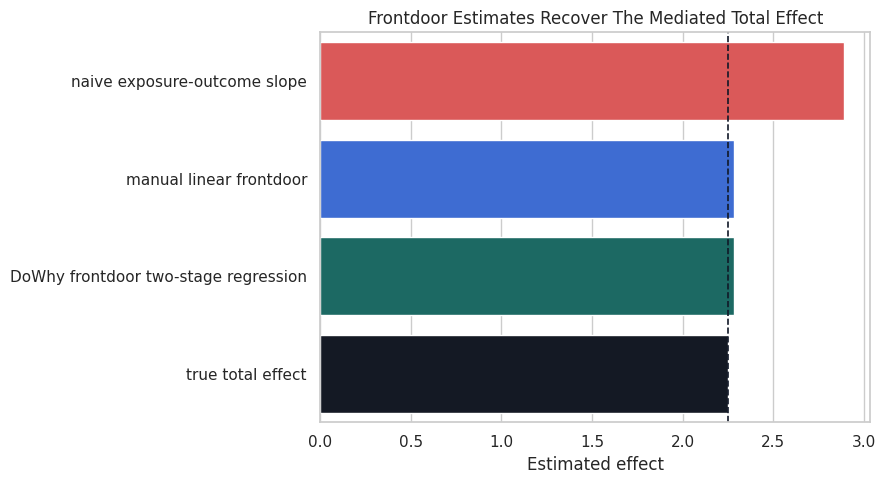

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
frontdoor_plot = dowhy_frontdoor_table.copy()
frontdoor_plot["display_order"] = range(len(frontdoor_plot))
colors = ["#ef4444", "#2563eb", "#0f766e", "#111827"]
sns.barplot(data=frontdoor_plot, x="estimate", y="estimator", palette=colors, ax=ax, hue="estimator", legend=False)
ax.axvline(frontdoor_true_effect, color="#111827", linestyle="--", linewidth=1.2)
ax.set_title("Frontdoor Estimates Recover The Mediated Total Effect")
ax.set_xlabel("Estimated effect")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_frontdoor_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The naive bar is the warning sign. It answers an associational question, while the frontdoor bars target the mediated causal effect implied by the graph.




#### Instrumental Variables: The Idea

An instrumental variable is a source of treatment variation that is as-good-as-random with respect to the outcome, except through the treatment itself. A common worked example is randomized encouragement: an assignment increases take-up, but assignment does not directly change the outcome.

For instrument `Z`, treatment `A`, outcome `Y`, and hidden confounder `U`, the core assumptions are:

- **Relevance:** `Z` changes `A`.
- **Independence:** `Z` is independent of hidden causes of `Y`.
- **Exclusion:** `Z` affects `Y` only through `A`.
- **Monotonicity:** if estimating a local average treatment effect, there are no systematic defiers.

We focus on the first three because they are the easiest to show in a compact simulation.




#### IV Assumption Checklist

The following table turns the IV assumptions into diagnostics and design questions. Only relevance is directly testable in the observed data. The other assumptions require design knowledge and careful argument.


| assumption | meaning | observable check |
| --- | --- | --- |
| Relevance | The instrument changes treatment exposure | First-stage coefficient and first-stage strength |
| Independence | The instrument is unrelated to hidden outcome causes | Balance checks on observed pre-treatment covariates, plus design knowledge |
| Exclusion | The instrument has no direct effect on the outcome except through treatment | Mostly a substantive argument; violated by direct messaging, information, or access paths |
| Monotonicity | The instrument does not push some units in the opposite direction | Usually argued from the assignment mechanism and treatment take-up logic |


The most common IV mistake is to celebrate a strong first stage while ignoring exclusion. A strong instrument can still be invalid if it changes the outcome through a second path.




#### Simulate an Encouragement Instrument

The next dataset has a randomized `rollout_assignment` that increases `feature_exposure`. Hidden motivation still affects both exposure and value, so ordinary regression is confounded. The instrument is valid because it is randomly assigned and has no direct path to `weekly_value` in the simulation.


In [11]:
# Define reusable helpers for the Simulate An Encouragement Instrument section.
def make_iv_data(n=8_000, seed=626):
    """
    Idea: Construct the IV data used in the Simulate An Encouragement Instrument section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n : int
        Number of observations or repetitions to generate.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple
        Tuple containing df, true_effect.
    """
    local_rng = np.random.default_rng(seed)
    unobserved_motivation = local_rng.normal(size=n)
    rollout_assignment = local_rng.binomial(n=1, p=0.50, size=n)
    true_effect = 1.70
    feature_exposure = (
        0.90 * rollout_assignment
        + 0.80 * unobserved_motivation
        + local_rng.normal(scale=1.00, size=n)
    )
    weekly_value = (
        true_effect * feature_exposure
        + 1.25 * unobserved_motivation
        + local_rng.normal(scale=1.15, size=n)
    )
    df = pd.DataFrame(
        {
            "rollout_assignment": rollout_assignment,
            "feature_exposure": feature_exposure,
            "weekly_value": weekly_value,
        }
    )
    return df, true_effect
iv_df, iv_true_effect = make_iv_data()
print(f"Rows: {len(iv_df):,}")
print(f"True treatment effect used in the simulation: {iv_true_effect:.2f}")
display(iv_df.head())


Rows: 8,000
True treatment effect used in the simulation: 1.70


,rollout_assignment,feature_exposure,weekly_value
0,1,2.0878,3.9934
1,1,1.6020,3.4766
2,1,3.2716,5.4254
3,1,1.7341,2.6352
4,0,1.7898,5.7876


The instrument is binary, while the treatment is continuous. That is a common encouragement design: assignment changes exposure intensity, but it does not perfectly determine exposure.


#### Check the First Stage and Reduced Form

The first stage estimates how much the instrument changes treatment. The reduced form estimates how much the instrument changes the outcome. The Wald IV estimate divides the reduced form by the first stage.

This ratio works in the simple single-instrument, single-treatment setting. It is a useful way to see what the IV estimator is doing before relying on any library abstraction.


In [12]:
iv_first_stage = smf.ols("feature_exposure ~ rollout_assignment", data=iv_df).fit(cov_type="HC1")
iv_reduced_form = smf.ols("weekly_value ~ rollout_assignment", data=iv_df).fit(cov_type="HC1")
iv_naive = smf.ols("weekly_value ~ feature_exposure", data=iv_df).fit(cov_type="HC1")
first_stage_effect = iv_first_stage.params["rollout_assignment"]
reduced_form_effect = iv_reduced_form.params["rollout_assignment"]
wald_iv_effect = reduced_form_effect / first_stage_effect
iv_stage_table = pd.DataFrame(
    [
        {"quantity": "naive exposure-outcome slope", "estimate": iv_naive.params["feature_exposure"]},
        {"quantity": "first stage: assignment -> exposure", "estimate": first_stage_effect},
        {"quantity": "reduced form: assignment -> outcome", "estimate": reduced_form_effect},
        {"quantity": "manual Wald IV ratio", "estimate": wald_iv_effect},
        {"quantity": "true treatment effect", "estimate": iv_true_effect},
    ]
)
iv_stage_table.to_csv(TABLE_DIR / "06_iv_manual_wald.csv", index=False)
display(iv_stage_table)
print(f"First-stage F statistic: {float(iv_first_stage.fvalue):.2f}")


,quantity,estimate
0,naive exposure-outcome slope,2.2692
1,first stage: assignment -> exposure,0.8892
2,reduced form: assignment -> outcome,1.5182
3,manual Wald IV ratio,1.7072
4,true treatment effect,1.7000


First-stage F statistic: 934.39


The first stage is strong, and the Wald ratio is close to the true effect. The naive slope is too high because it mixes the treatment effect with hidden motivation.


#### A Simple Two-Stage Regression View

Two-stage least squares can be understood as replacing the confounded treatment with the part of treatment predicted by the instrument. In this simple example, that predicted exposure is a function of randomized assignment.

The point estimate below is a teaching implementation. Production IV analyses usually use dedicated IV routines for standard errors and richer specifications.


In [13]:
iv_df_for_2sls = iv_df.copy()
iv_df_for_2sls["predicted_exposure"] = iv_first_stage.fittedvalues
iv_second_stage = smf.ols("weekly_value ~ predicted_exposure", data=iv_df_for_2sls).fit(cov_type="HC1")
iv_2sls_table = pd.DataFrame(
    [
        {"estimator": "manual Wald IV ratio", "estimate": wald_iv_effect},
        {"estimator": "simple two-stage regression", "estimate": iv_second_stage.params["predicted_exposure"]},
        {"estimator": "true treatment effect", "estimate": iv_true_effect},
    ]
)
iv_2sls_table.to_csv(TABLE_DIR / "06_iv_two_stage.csv", index=False)
display(iv_2sls_table)


,estimator,estimate
0,manual Wald IV ratio,1.7072
1,simple two-stage regression,1.7072
2,true treatment effect,1.7000


The simple two-stage point estimate matches the Wald ratio because there is one binary instrument and one continuous treatment. The important conceptual move is that the second stage uses only instrument-induced exposure variation.


#### Estimate the IV Effect with DoWhy

Now we encode the IV graph in DoWhy. The hidden variable is included in the graph and omitted from the dataframe, just as in the frontdoor example. The instrument is `rollout_assignment`.


In [14]:
iv_graph = edges_to_dot(
    [
        ("unobserved_motivation", "feature_exposure"),
        ("unobserved_motivation", "weekly_value"),
        ("rollout_assignment", "feature_exposure"),
        ("feature_exposure", "weekly_value"),
    ],
    graph_name="iv_graph",
)
iv_model = CausalModel(
    data=iv_df,
    treatment="feature_exposure",
    outcome="weekly_value",
    graph=iv_graph,
    instruments=["rollout_assignment"],
)
iv_estimand = iv_model.identify_effect(proceed_when_unidentifiable=True)
print(iv_estimand)


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
No such variable(s) found!

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                                             ↪
 ⎢          d                        ⎛          d                              ↪
E⎢─────────────────────(weeklyᵥₐₗᵤₑ)⋅⎜─────────────────────([featureₑₓₚₒₛᵤᵣₑ]) ↪
 ⎣d[rollout_assignment]              ⎝d[rollout_assignment]                    ↪

↪  -1⎤
↪ ⎞  ⎥
↪ ⎟  ⎥
↪ ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→weekly_value then ¬(U →→{rollout_assignment})
Estimand assumption 2, Exclusion: If we remove {rollout_assignment}→{feature_exposure}, then ¬({rollout_assignment}→weekly_value)

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



The estimand output should show that DoWhy recognizes the instrument. This is the model-identify step from the core DoWhy workflow, now applied to an IV design instead of a backdoor design.




#### Compare DoWhy IV with the Manual Estimates

The DoWhy IV estimator gives the same causal target in this simple setting. Comparing it with the manual Wald ratio is a useful sanity check.


In [15]:
iv_dowhy_estimate = iv_model.estimate_effect(
    iv_estimand,
    method_name="iv.instrumental_variable",
)
iv_comparison = pd.DataFrame(
    [
        {"estimator": "naive exposure-outcome slope", "estimate": iv_naive.params["feature_exposure"]},
        {"estimator": "manual Wald IV ratio", "estimate": wald_iv_effect},
        {"estimator": "simple two-stage regression", "estimate": iv_second_stage.params["predicted_exposure"]},
        {"estimator": "DoWhy instrumental variable", "estimate": iv_dowhy_estimate.value},
        {"estimator": "true treatment effect", "estimate": iv_true_effect},
    ]
)
iv_comparison.to_csv(TABLE_DIR / "06_iv_estimator_comparison.csv", index=False)
display(iv_comparison)


,estimator,estimate
0,naive exposure-outcome slope,2.2692
1,manual Wald IV ratio,1.7072
2,simple two-stage regression,1.7072
3,DoWhy instrumental variable,1.7072
4,true treatment effect,1.7000


The IV estimates line up because they are using the same assignment-driven variation. The naive slope remains different because it uses all variation in exposure, including the part driven by hidden motivation.




#### Visualize the Instrument's First Stage

A valid instrument must move treatment. This plot shows the average exposure and average outcome by assignment group. The exposure jump is the first stage; the outcome jump is the reduced form.


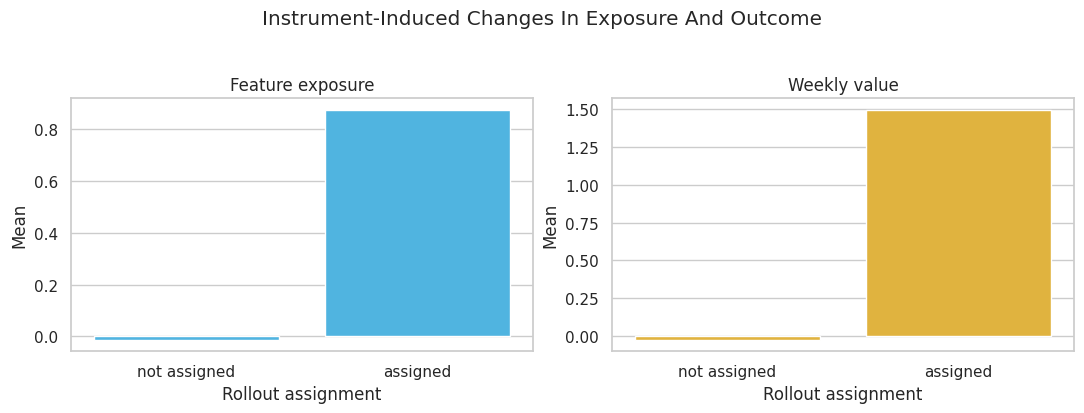

In [16]:
# Build and label the diagnostic visualization for the Visualize The Instrument's First Stage section.
iv_means = (
    iv_df.groupby("rollout_assignment")
    .agg(
        mean_exposure=("feature_exposure", "mean"),
        mean_value=("weekly_value", "mean"),
        rows=("weekly_value", "size"),
    )
    .reset_index()
)
iv_long = iv_means.melt(
    id_vars=["rollout_assignment", "rows"],
    value_vars=["mean_exposure", "mean_value"],
    var_name="quantity",
    value_name="mean",
)
iv_long["assignment_label"] = iv_long["rollout_assignment"].map({0: "not assigned", 1: "assigned"})
iv_long["quantity"] = iv_long["quantity"].map({"mean_exposure": "Feature exposure", "mean_value": "Weekly value"})
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=False)
for ax, quantity in zip(axes, ["Feature exposure", "Weekly value"]):
    sns.barplot(
        data=iv_long[iv_long["quantity"] == quantity],
        x="assignment_label",
        y="mean",
        color="#38bdf8" if quantity == "Feature exposure" else "#fbbf24",
        ax=ax,
    )
    ax.set_title(quantity)
    ax.set_xlabel("Rollout assignment")
    ax.set_ylabel("Mean")
fig.suptitle("Instrument-Induced Changes In Exposure And Outcome", y=1.03)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_iv_first_stage_reduced_form.png", dpi=160, bbox_inches="tight")
plt.show()


The two bars for exposure should differ clearly. If an instrument barely changes treatment, the resulting IV estimate becomes unstable even if the graph is theoretically valid.


#### Natural Experiments: Design Before Estimator

Frontdoor and IV fit naturally into DoWhy's identify-estimate API. Some natural-experiment designs are better introduced as design-specific analyses first.

The next two examples keep the design logic transparent:

- **Regression discontinuity:** a treatment rule changes sharply at a threshold.
- **Difference-in-differences:** a treated group changes after treatment relative to an untreated comparison group.

The purpose here is to understand the estimand logic, not to replace specialized econometrics packages.


#### Regression Discontinuity Setup

In a fuzzy regression discontinuity design, crossing a cutoff changes treatment probability or treatment intensity, but does not perfectly determine treatment. The causal estimate near the cutoff is the outcome jump divided by the treatment jump.

The key assumption is local smoothness: units just below and just above the cutoff would have had similar potential outcomes if treatment exposure had not jumped.


In [17]:
# Define reusable helpers for the Regression Discontinuity Setup section.
def make_rd_data(n=30_000, seed=636):
    """
    Idea: Construct the regression discontinuity data used in the Regression Discontinuity Setup section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n : int
        Number of observations or repetitions to generate.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple
        Tuple containing df, true_effect.
    """
    local_rng = np.random.default_rng(seed)
    running_score = local_rng.uniform(-2.0, 2.0, size=n)
    threshold_assignment = (running_score >= 0).astype(int)
    unobserved_quality = local_rng.normal(size=n)
    true_effect = 1.35
    feature_exposure = (
        0.85 * threshold_assignment
        + 0.35 * running_score
        + 0.35 * unobserved_quality
        + local_rng.normal(scale=0.70, size=n)
    )
    weekly_value = (
        true_effect * feature_exposure
        + 1.00 * running_score
        + 0.35 * running_score**2
        + 0.65 * unobserved_quality
        + local_rng.normal(scale=1.00, size=n)
    )
    df = pd.DataFrame(
        {
            "running_score": running_score,
            "threshold_assignment": threshold_assignment,
            "feature_exposure": feature_exposure,
            "weekly_value": weekly_value,
        }
    )
    return df, true_effect
rd_df, rd_true_effect = make_rd_data()
print(f"Rows: {len(rd_df):,}")
print(f"True local treatment effect used in the simulation: {rd_true_effect:.2f}")
display(rd_df.head())


Rows: 30,000
True local treatment effect used in the simulation: 1.35


,running_score,threshold_assignment,feature_exposure,weekly_value
0,-0.5057,0,0.8723,1.6547
1,-1.6145,0,-0.8022,-0.6525
2,-1.6179,0,-0.2519,-1.1858
3,0.4025,1,1.1149,1.9999
4,0.2709,1,0.7904,1.9649


The treatment is continuous, and the cutoff changes its average level. The outcome also changes smoothly with the running score, so we need to compare units locally around the cutoff rather than across the entire score range.


#### Visualize the Cutoff

This binned scatterplot shows how treatment and outcome behave around the threshold. We bin the running score only for visualization. The estimation step below uses the individual rows inside local bandwidths.


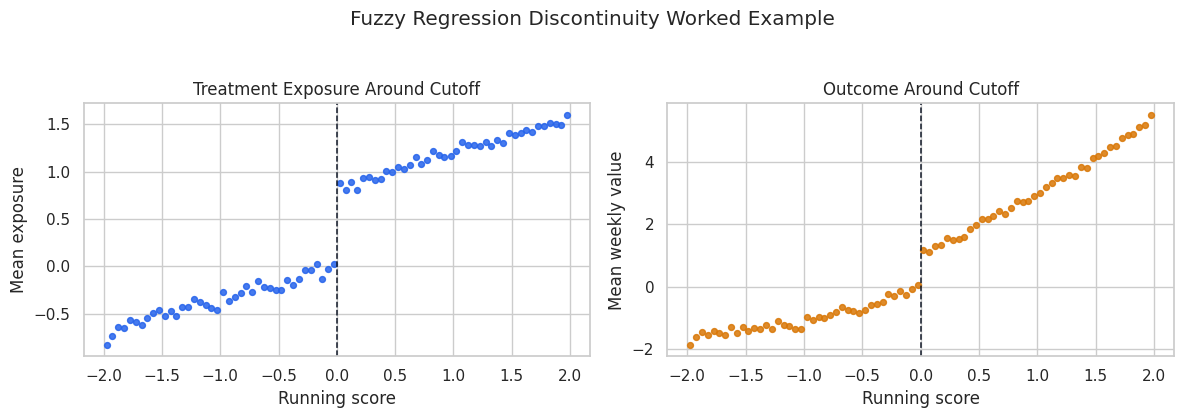

In [18]:
# Build and label the diagnostic visualization for the Visualize The Cutoff section.
rd_plot_df = rd_df.copy()
rd_plot_df["score_bin"] = pd.cut(rd_plot_df["running_score"], bins=np.linspace(-2, 2, 81), include_lowest=True)
rd_binned = (
    rd_plot_df.groupby("score_bin", observed=True)
    .agg(
        score_mid=("running_score", "mean"),
        mean_exposure=("feature_exposure", "mean"),
        mean_value=("weekly_value", "mean"),
        rows=("weekly_value", "size"),
    )
    .reset_index(drop=True)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
axes[0].scatter(rd_binned["score_mid"], rd_binned["mean_exposure"], s=18, color="#2563eb", alpha=0.85)
axes[0].axvline(0, color="#111827", linestyle="--", linewidth=1.1)
axes[0].set_title("Treatment Exposure Around Cutoff")
axes[0].set_xlabel("Running score")
axes[0].set_ylabel("Mean exposure")
axes[1].scatter(rd_binned["score_mid"], rd_binned["mean_value"], s=18, color="#d97706", alpha=0.85)
axes[1].axvline(0, color="#111827", linestyle="--", linewidth=1.1)
axes[1].set_title("Outcome Around Cutoff")
axes[1].set_xlabel("Running score")
axes[1].set_ylabel("Mean weekly value")
fig.suptitle("Fuzzy Regression Discontinuity Worked Example", y=1.04)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_rd_binned_cutoff_patterns.png", dpi=160, bbox_inches="tight")
plt.show()


The treatment jump at zero is the design's engine. The outcome jump is not by itself the treatment effect because exposure is fuzzy; the fuzzy RD estimate scales the outcome jump by the treatment jump.




#### Estimate a Fuzzy RD Across Bandwidths

Bandwidth choice controls the locality of the comparison. A narrow bandwidth compares units very close to the cutoff but uses fewer rows. A wider bandwidth uses more rows but relies more heavily on the local linear model.

For each bandwidth, we estimate two jumps at the cutoff: one for the outcome and one for the treatment. The fuzzy RD estimate is `outcome_jump / treatment_jump`.


In [19]:
# Define reusable helpers for the Estimate A Fuzzy RD Across Bandwidths section.
def fuzzy_rd_at_bandwidth(data, bandwidth):
    """
    Idea: Compute the fuzzy regression discontinuity at bandwidth needed in the Estimate A Fuzzy RD Across Bandwidths section and return it in a form the next cells can inspect.
    
    Parameters
    ----------
    data : array-like or pd.DataFrame
        Data passed into the demonstrated method.
    bandwidth : object
        Context-specific input used for bandwidth in this helper.
    
    Returns
    -------
    dict[str, float]
        Fuzzy-RD row with bandwidth, jumps, Wald estimate, and oracle error.
    """
    local = data.loc[data["running_score"].abs() <= bandwidth].copy()
    local["score_x_assignment"] = local["running_score"] * local["threshold_assignment"]
    outcome_model = smf.ols(
        "weekly_value ~ threshold_assignment + running_score + score_x_assignment",
        data=local,
    ).fit(cov_type="HC1")
    treatment_model = smf.ols(
        "feature_exposure ~ threshold_assignment + running_score + score_x_assignment",
        data=local,
    ).fit(cov_type="HC1")
    outcome_jump = outcome_model.params["threshold_assignment"]
    treatment_jump = treatment_model.params["threshold_assignment"]
    fuzzy_estimate = outcome_jump / treatment_jump
    return {
        "bandwidth": bandwidth,
        "rows": len(local),
        "outcome_jump": outcome_jump,
        "treatment_jump": treatment_jump,
        "fuzzy_rd_estimate": fuzzy_estimate,
        "true_effect": rd_true_effect,
        "absolute_error": abs(fuzzy_estimate - rd_true_effect),
    }
rd_bandwidth_table = pd.DataFrame(
    [fuzzy_rd_at_bandwidth(rd_df, bandwidth) for bandwidth in [0.25, 0.50, 0.75, 1.00]]
)
rd_bandwidth_table.to_csv(TABLE_DIR / "06_rd_bandwidth_sensitivity.csv", index=False)
display(rd_bandwidth_table)


,bandwidth,rows,outcome_jump,treatment_jump,fuzzy_rd_estimate,true_effect,absolute_error
0,0.2500,3723,0.9578,0.8175,1.1716,1.3500,0.1784
1,0.5000,7425,0.9778,0.7804,1.2530,1.3500,0.0970
2,0.7500,11165,1.0335,0.7973,1.2963,1.3500,0.0537
3,1.0000,14955,1.0754,0.8149,1.3197,1.3500,0.0303


The estimates should cluster around the true effect. They are not identical because each bandwidth makes a slightly different locality tradeoff.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Plot RD Bandwidth Sensitivity

A bandwidth sensitivity plot is a compact way to show whether the design is fragile. If the estimate moves wildly as the bandwidth changes, the causal reading should become more cautious.


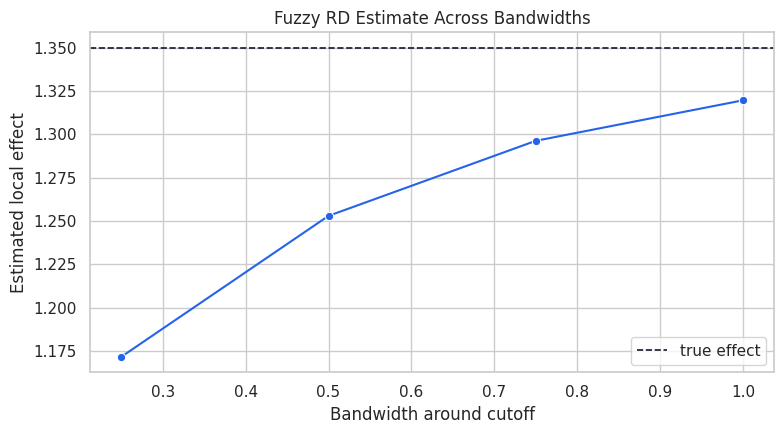

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(
    data=rd_bandwidth_table,
    x="bandwidth",
    y="fuzzy_rd_estimate",
    marker="o",
    color="#2563eb",
    ax=ax,
)
ax.axhline(rd_true_effect, color="#111827", linestyle="--", linewidth=1.2, label="true effect")
ax.set_title("Fuzzy RD Estimate Across Bandwidths")
ax.set_xlabel("Bandwidth around cutoff")
ax.set_ylabel("Estimated local effect")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_rd_bandwidth_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


The curve is the design's stability check. In real work, we would also inspect covariate balance around the cutoff, density manipulation, and alternative polynomial or local-linear specifications.




#### Difference-In-Differences Setup

Difference-in-differences compares changes over time. If the treated group and comparison group would have followed parallel trends without treatment, then the extra post-period change in the treated group can be read as the treatment effect.

The minimal two-period version has four cells: treated pre, treated post, control pre, and control post.


In [21]:
# Define reusable helpers for the Difference-In-Differences Setup section.
def make_did_data(n_units=4_000, seed=646):
    """
    Idea: Construct the difference-in-differences data used in the Difference-In-Differences Setup section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n_units : object
        Number of units generated for the panel or repeated-observation simulation.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple
        Tuple containing pd.concat(rows, ignore_index=True), true_effect, used to keep the fitted model and reporting fields together.
    """
    local_rng = np.random.default_rng(seed)
    unit_id = np.arange(n_units)
    treated_group = local_rng.binomial(n=1, p=0.50, size=n_units)
    unit_quality = local_rng.normal(size=n_units)
    true_effect = 1.20
    rows = []
    for post_period in [0, 1]:
        untreated_trend = 0.70 * post_period
        treatment = treated_group * post_period
        weekly_value = (
            5.00
            + 1.10 * treated_group
            + 1.40 * unit_quality
            + untreated_trend
            + true_effect * treatment
            + local_rng.normal(scale=1.00, size=n_units)
        )
        rows.append(
            pd.DataFrame(
                {
                    "unit_id": unit_id,
                    "treated_group": treated_group,
                    "post_period": post_period,
                    "treatment": treatment,
                    "weekly_value": weekly_value,
                }
            )
        )
    return pd.concat(rows, ignore_index=True), true_effect
did_df, did_true_effect = make_did_data()
print(f"Rows: {len(did_df):,}")
print(f"Units: {did_df['unit_id'].nunique():,}")
print(f"True treatment effect used in the simulation: {did_true_effect:.2f}")
display(did_df.head())


Rows: 8,000
Units: 4,000
True treatment effect used in the simulation: 1.20


,unit_id,treated_group,post_period,treatment,weekly_value
0,0,0,0,0,1.3949
1,1,0,0,0,6.6459
2,2,0,0,0,4.7025
3,3,0,0,0,8.5818
4,4,1,0,0,5.4307


Each unit appears once before and once after. Treated units receive treatment only in the post period, so the `treatment` column is the interaction of treated group and post period.


#### Compute the Four DiD Cell Means

The simplest DiD estimate comes from four means. We calculate the treated change, the control change, and then subtract the two changes.


In [22]:
did_cell_means = (
    did_df.groupby(["treated_group", "post_period"])
    .agg(mean_value=("weekly_value", "mean"), rows=("weekly_value", "size"))
    .reset_index()
)
did_cell_table = did_cell_means.pivot(index="treated_group", columns="post_period", values="mean_value")
did_cell_table = did_cell_table.rename(index={0: "control group", 1: "treated group"}, columns={0: "pre", 1: "post"})
did_cell_table["change"] = did_cell_table["post"] - did_cell_table["pre"]
manual_did = did_cell_table.loc["treated group", "change"] - did_cell_table.loc["control group", "change"]
did_cell_table.to_csv(TABLE_DIR / "06_did_cell_means.csv")
display(did_cell_table)
print(f"Manual difference-in-differences estimate: {manual_did:.3f}")


post_period,pre,post,change
treated_group,,,
control group,4.9778,5.6600,0.6822
treated group,6.1463,7.9809,1.8346


Manual difference-in-differences estimate: 1.152


The treated group starts at a different level, which is allowed in DiD. The design uses differences in changes, not equality of pre-period levels.


#### Estimate DiD with a Regression Interaction

The standard two-period DiD regression includes group, time, and their interaction. The interaction coefficient equals the manual DiD estimate from the four-cell table.


In [23]:
did_regression = smf.ols(
    "weekly_value ~ treated_group + post_period + treated_group:post_period",
    data=did_df,
).fit(cov_type="cluster", cov_kwds={"groups": did_df["unit_id"]})
did_regression_table = pd.DataFrame(
    [
        {"quantity": "manual DiD", "estimate": manual_did, "std_error": np.nan},
        {
            "quantity": "regression interaction",
            "estimate": did_regression.params["treated_group:post_period"],
            "std_error": did_regression.bse["treated_group:post_period"],
        },
        {"quantity": "true treatment effect", "estimate": did_true_effect, "std_error": np.nan},
    ]
)
did_regression_table.to_csv(TABLE_DIR / "06_did_regression_estimate.csv", index=False)
display(did_regression_table)


,quantity,estimate,std_error
0,manual DiD,1.1524,NaN
1,regression interaction,1.1524,0.0443
2,true treatment effect,1.2000,NaN


The regression and manual estimate match because they are algebraically the same in this two-period setup. The regression form becomes more convenient when adding covariates, fixed effects, or more time periods.


#### Visualize the DiD Design

The parallel-trends idea is easiest to see as a line chart. The vertical distance between lines before treatment can differ. The causal claim is about whether the treated line would have moved like the control line in the absence of treatment.


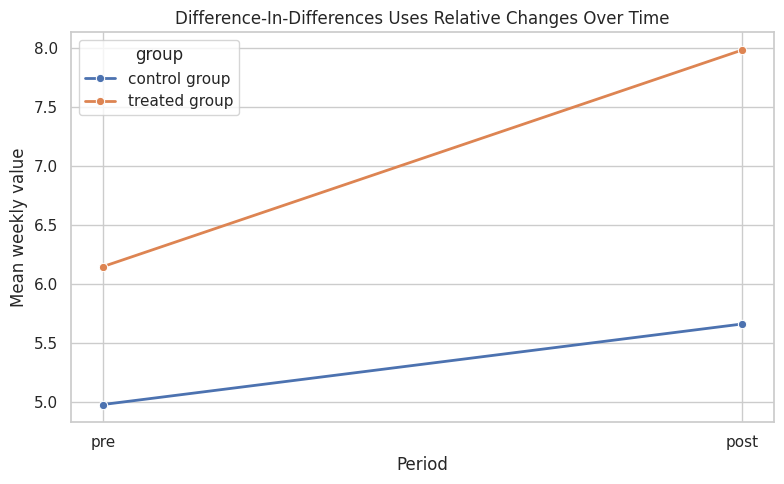

In [24]:
did_plot = did_cell_means.copy()
did_plot["group"] = did_plot["treated_group"].map({0: "control group", 1: "treated group"})
did_plot["period"] = did_plot["post_period"].map({0: "pre", 1: "post"})
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(
    data=did_plot,
    x="period",
    y="mean_value",
    hue="group",
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.set_title("Difference-In-Differences Uses Relative Changes Over Time")
ax.set_xlabel("Period")
ax.set_ylabel("Mean weekly value")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_did_group_time_means.png", dpi=160, bbox_inches="tight")
plt.show()


The treated group rises more after treatment than the control group. Under the parallel-trends assumption, that extra rise is the causal effect.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->




#### Compare the Designs

Now we combine the estimates from the lesson. These methods do not all estimate the exact same population estimand in real applications. Here, the simulations were built so that each design has a clear known target.


In [25]:
design_comparison = pd.DataFrame(
    [
        {
            "design": "hidden-confounding naive regression",
            "estimate": hidden_estimates.loc[hidden_estimates["model"] == "naive association", "estimate"].iloc[0],
            "target": hidden_true_effect,
            "main lesson": "Association is biased when hidden common causes drive treatment and outcome",
        },
        {
            "design": "frontdoor with measured mediator",
            "estimate": frontdoor_estimate.value,
            "target": frontdoor_true_effect,
            "main lesson": "A valid mediator can identify the total effect despite hidden treatment-outcome confounding",
        },
        {
            "design": "instrumental variable",
            "estimate": iv_dowhy_estimate.value,
            "target": iv_true_effect,
            "main lesson": "A valid instrument isolates assignment-driven treatment variation",
        },
        {
            "design": "fuzzy regression discontinuity",
            "estimate": rd_bandwidth_table.loc[rd_bandwidth_table["bandwidth"] == 0.50, "fuzzy_rd_estimate"].iloc[0],
            "target": rd_true_effect,
            "main lesson": "A cutoff can identify a local effect near the threshold",
        },
        {
            "design": "difference-in-differences",
            "estimate": did_regression.params["treated_group:post_period"],
            "target": did_true_effect,
            "main lesson": "A comparison-group trend can stand in for the treated group's missing counterfactual trend",
        },
    ]
)
design_comparison["error"] = design_comparison["estimate"] - design_comparison["target"]
design_comparison.to_csv(TABLE_DIR / "06_design_comparison.csv", index=False)
display(design_comparison)


,design,estimate,target,main lesson,error
0,hidden-confounding naive regression,2.1598,1.5000,Association is biased when hidden common causes drive treatment and outcome,0.6598
1,frontdoor with measured mediator,2.2823,2.2500,A valid mediator can identify the total effect despite hidden treatment-outcome confounding,0.0323
2,instrumental variable,1.7072,1.7000,A valid instrument isolates assignment-driven treatment variation,0.0072
3,fuzzy regression discontinuity,1.2530,1.3500,A cutoff can identify a local effect near the threshold,-0.0970
4,difference-in-differences,1.1524,1.2000,A comparison-group trend can stand in for the treated group's missing counterfactual trend,-0.0476


The table is a reminder that design quality matters more than estimator complexity. The right question is more than “what model did we fit?” but “what source of variation made the causal contrast believable?”




#### Final Figure: Estimates versus Targets

This final plot puts each design next to its target. The hidden-confounding naive regression is included as a deliberate failure case. The other designs are not universally better; they work here because their assumptions were built into the data-generating process.


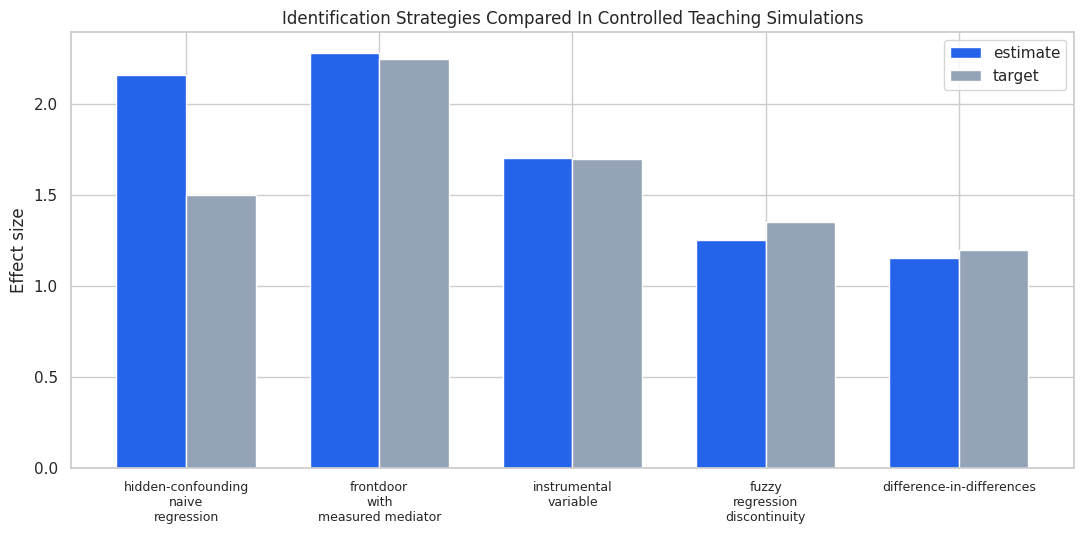

In [26]:
fig, ax = plt.subplots(figsize=(11, 5.5))
plot_designs = design_comparison.copy()
plot_designs["design_wrapped"] = plot_designs["design"].str.replace(" ", "\n", n=2)
x = np.arange(len(plot_designs))
width = 0.36
ax.bar(x - width / 2, plot_designs["estimate"], width=width, label="estimate", color="#2563eb")
ax.bar(x + width / 2, plot_designs["target"], width=width, label="target", color="#94a3b8")
ax.set_xticks(x)
ax.set_xticklabels(plot_designs["design_wrapped"], fontsize=9)
ax.set_ylabel("Effect size")
ax.set_title("Identification Strategies Compared In Controlled Teaching Simulations")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_design_estimates_vs_targets.png", dpi=160, bbox_inches="tight")
plt.show()


The visual contrast is useful when presenting the lesson: ordinary regression is not wrong because it is simple; it is wrong because the identifying variation is contaminated. Frontdoor, IV, RD, and DiD each try to locate cleaner variation under different assumptions.




#### Practical Checklist for Real Analyses

When using these designs outside a simulation, document the assumptions in plain language before showing the final number.

- For frontdoor, explain why the mediator carries the treatment effect and why mediator-outcome confounding is controlled.
- For IV, explain instrument relevance, independence, exclusion, and monotonicity.
- For RD, show the cutoff rule, local balance, density around the cutoff, and bandwidth sensitivity.
- For DiD, show pre-trends when possible and explain why the comparison group is credible.
- For all designs, report what would make the estimate fail.

A strong causal analysis should make the identifying assumption easy to find, easy to criticize, and easy to connect to the estimator.




#### Practice Prompts

Use these prompts to extend the lesson:

1. Add a direct effect from `feature_exposure` to `weekly_value` in the frontdoor simulation. How quickly does the frontdoor estimate become misleading?
2. Add a direct effect from `rollout_assignment` to `weekly_value` in the IV simulation. Compare the naive, Wald, and DoWhy estimates.
3. In the RD simulation, let units manipulate the running score near zero. How does the cutoff plot change?
4. In the DiD simulation, give the treated group a faster untreated trend. How does the interaction coefficient change?
5. Write one paragraph for each design explaining the strongest assumption in language a non-technical stakeholder could challenge.




#### What Comes Next

The sequence next moves from average effects to heterogeneous effects. Once identification is credible, the natural follow-up is to ask whether the effect is larger for some units than others. Heterogeneity models can be useful, but they should still sit on top of a clear causal design.


## Summary

This lesson compared several identification strategies, including frontdoor adjustment, instrumental variables, regression discontinuity, and difference-in-differences. The shared message is that an estimator gets its meaning from the source of variation and the assumptions that make that variation credible. In applied work, the final number should travel with the design argument, diagnostics, and the failure modes that would change the conclusion.
